# Corpus Metrics

| Column | Meaning |
|--------|---------|
| `language` | Language name |
| `script` | Dominant script |
| `original_token_count` | Original token count |
| `current_type_count` | Current type count |
| `type_token_ratio` | Type-token ratio |
| `avg_type_length` | Average type length |
| `token_frequency_entropy` | Token frequency entropy |
| `compress_reduction_pct` | Compressibility (reduction %) |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "notebooks" / "scripts"))
import graph_export

FONT_SIZE = 12
plt.rcParams.update({"font.size": FONT_SIZE})

df_all = pd.read_csv(ROOT / "results" / "3_analyze" / "total_results.csv")

df = df_all.drop_duplicates(subset="lang", keep="first").copy()
df.rename(columns={"language_name": "language"}, inplace=True)

print(f"Total rows: {len(df_all)}, Deduplicated: {len(df)}")
df[["lang", "language", "script", "family", "genus", "typology",
    "original_token_count", "type_token_ratio", "token_frequency_entropy"]].head(20)

Total rows: 175, Deduplicated: 173


,lang,language,script,family,genus,typology,original_token_count,type_token_ratio,token_frequency_entropy
0,abk,Abkhaz,Cyrl,Northwest Caucasian,Northwest Caucasian,Polysynthetic,3547931,0.425561,14.796891
1,afr,Afrikaans,Latn,Indo-European,Germanic,Isolating,409850019,0.028675,9.762891
2,als,Tosk Albanian,Latn,Indo-European,Albanian,Fusional,99291068,0.094831,11.257853
3,amh,Amharic,Ethi,Afro-Asiatic,Semitic,Introflexive,99815231,0.886847,14.796068
4,ara,Arabic,Arab,Afro-Asiatic,Semitic,Introflexive,867255773,0.178168,13.211496
5,arg,Aragonese,Latn,Indo-European,Romance,Fusional,12301588,0.063319,10.629617
6,arz,Arabic (Egyptian),Arab,Afro-Asiatic,Semitic,Introflexive,45335001,0.232202,11.325129
7,asm,Assamese,Beng,Indo-European,Indic,Fusional,46572832,0.150306,13.080080
8,ast,Asturian,Latn,Indo-European,Romance,Fusional,162513226,0.079123,11.038981
9,aze,Azerbaijani,Latn,Altaic,Turkic,Agglutinative,494773437,0.287817,13.542199


In [157]:
print("=== TTR: 5 highest ===")
print(df.nlargest(5, "type_token_ratio")[["language", "type_token_ratio"]].to_string(index=False))
print("\n=== TTR: 5 lowest ===")
print(df.nsmallest(5, "type_token_ratio")[["language", "type_token_ratio"]].to_string(index=False))

print("\n=== Entropy: 5 highest ===")
print(df.nlargest(5, "token_frequency_entropy")[["language", "token_frequency_entropy"]].to_string(index=False))
print("\n=== Entropy: 5 lowest ===")
print(df.nsmallest(5, "token_frequency_entropy")[["language", "token_frequency_entropy"]].to_string(index=False))

=== TTR: 5 highest ===
       language  type_token_ratio
         Korean          2.370185
Zulu (Southern)          2.128293
      Malayalam          1.936165
        Maltese          1.280066
      Inuktitut          1.184056

=== TTR: 5 lowest ===
       language  type_token_ratio
     Vietnamese          0.002518
        Volapük          0.004017
Nigerian Pidgin          0.004763
     Papiamentu          0.009374
     Cakchiquel          0.010245

=== Entropy: 5 highest ===
       language  token_frequency_entropy
         Korean                15.754332
      Malayalam                15.605119
Zulu (Southern)                15.419607
      Inuktitut                15.139441
         Abkhaz                14.796891

=== Entropy: 5 lowest ===
        language  token_frequency_entropy
         Volapük                 7.293128
     Waray-Waray                 7.553272
Plateau Malagasy                 7.901136
         Cebuano                 8.193999
         Walloon                 8.

graph_export: saved ttrToEntropy.pdf


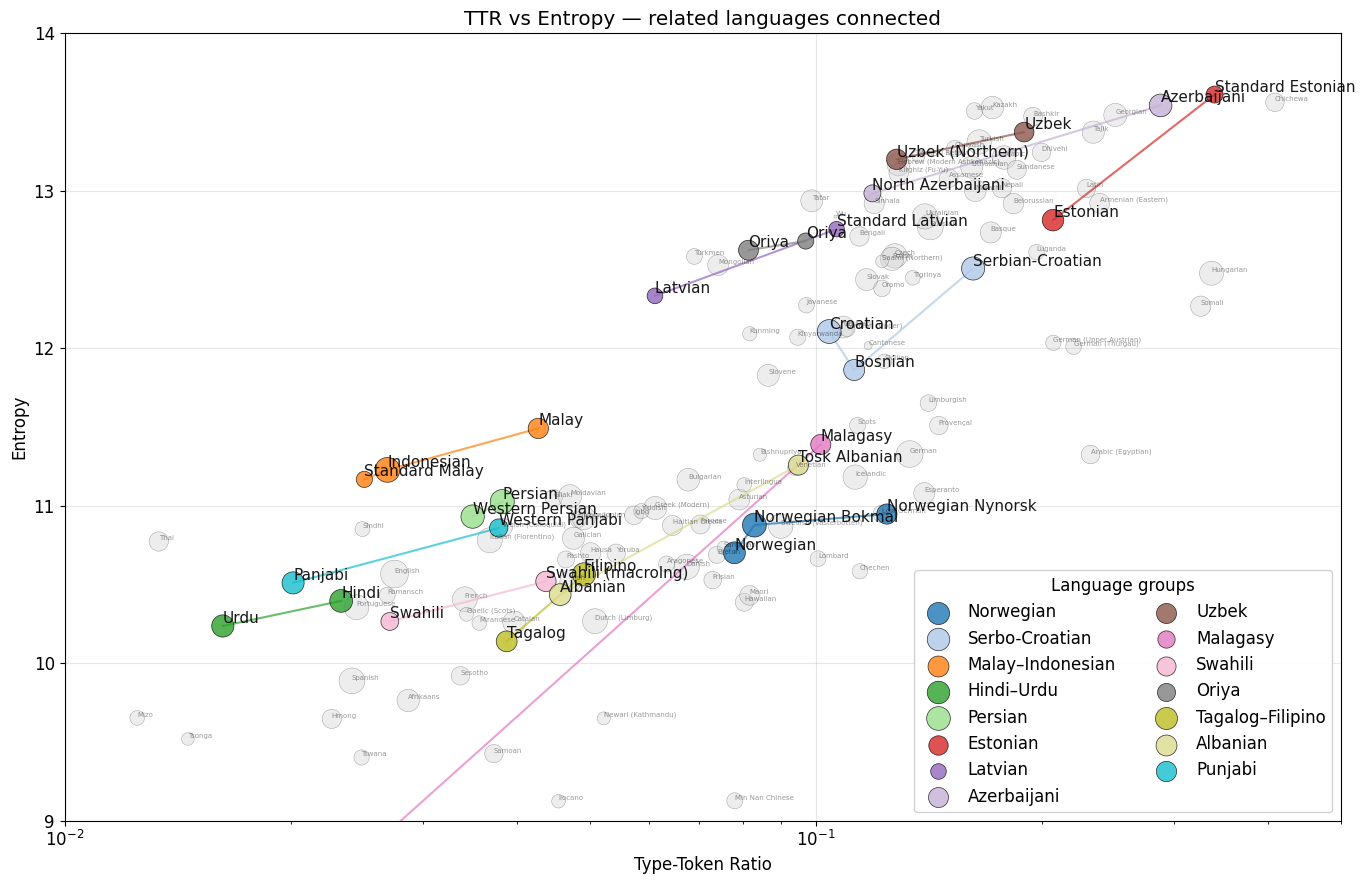

In [ ]:
RELATED_GROUPS = [
    ("Norwegian", ["nno", "nob", "nor"]),
    ("Serbo-Croatian", ["hbs", "hrv", "bos", "srp"]),
    ("Malay–Indonesian", ["ind", "msa", "zsm"]),
    ("Hindi–Urdu", ["hin", "urd"]),
    ("Persian", ["fas", "pes"]),
    ("Estonian", ["est", "ekk"]),
    ("Latvian", ["lav", "lvs"]),
    ("Azerbaijani", ["aze", "azj"]),
    ("Uzbek", ["uzb", "uzn"]),
    ("Malagasy", ["mlg", "plt"]),
    ("Swahili", ["swa", "swh"]),
    ("Oriya", ["ori", "ory"]),
    ("Tagalog–Filipino", ["tgl", "fil"]),
    ("Albanian", ["als", "sqi"]),
    ("Punjabi", ["pan", "pnb"]),
]

fig, ax = plt.subplots(figsize=(14, 9))

lang_to_group = {}
for i, (name, codes) in enumerate(RELATED_GROUPS):
    for code in codes:
        lang_to_group[code] = i

grouped_mask = df["lang"].isin(lang_to_group)
df_ungrouped = df[~grouped_mask]
df_grouped = df[grouped_mask]

min_size, max_size = 5, 400
log_tkc = np.log10(df["original_token_count"].clip(lower=1))
sizes = min_size + (log_tkc - log_tkc.min()) / (log_tkc.max() - log_tkc.min()) * (max_size - min_size)

ax.scatter(
    df_ungrouped["type_token_ratio"], df_ungrouped["token_frequency_entropy"],
    s=sizes[~grouped_mask], alpha=0.4, c="lightgray", edgecolors="k", linewidths=0.3,
)

cmap = plt.cm.tab20
for i, (name, codes) in enumerate(RELATED_GROUPS):
    members = df[df["lang"].isin(codes)]
    if len(members) < 2:
        continue
    color = cmap(i / len(RELATED_GROUPS))
    ax.scatter(
        members["type_token_ratio"], members["token_frequency_entropy"],
        s=sizes[members.index], alpha=0.8, c=[color],
        edgecolors="k", linewidths=0.5, label=name, zorder=3,
    )
    sorted_m = members.sort_values("type_token_ratio")
    ax.plot(sorted_m["type_token_ratio"].values, sorted_m["token_frequency_entropy"].values,
            c=color, linewidth=1.5, alpha=0.7, zorder=2)

for _, row in df_grouped.iterrows():
    ax.annotate(row["language"], (row["type_token_ratio"], row["token_frequency_entropy"]),
                fontsize=11, alpha=0.9, ha="left", va="bottom")
for _, row in df_ungrouped.iterrows():
    ax.annotate(row["language"], (row["type_token_ratio"], row["token_frequency_entropy"]),
                fontsize=5, alpha=0.4, ha="left", va="bottom")

ax.set_xlim(0.01, 0.5)
ax.set_ylim(9, 14)
ax.set_xlabel("Type-Token Ratio")
ax.set_xscale("log")
ax.set_ylabel("Entropy")
ax.set_title("TTR vs Entropy — related languages connected")
ax.grid(alpha=0.3)
ax.legend(title="Language groups", loc="lower right", fontsize=12, framealpha=0.9, ncol=2, title_fontsize=12)

plt.tight_layout()
graph_export.save("ttrToEntropy", fig)
plt.show()

graph_export: saved entropyToCompressibility.pdf


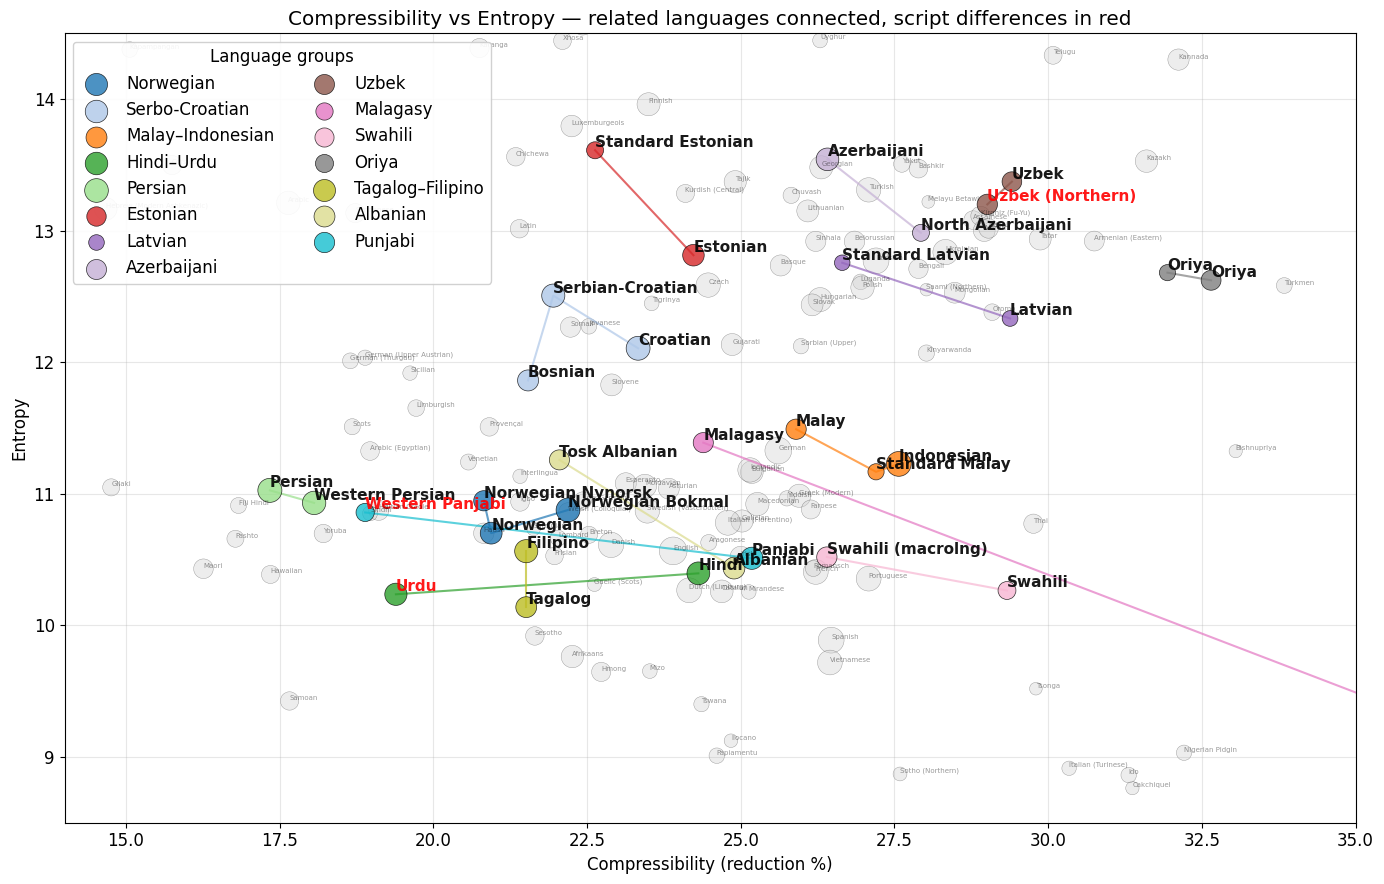

In [ ]:
df_comp = df.dropna(subset=["compress_reduction_pct"]).copy()

fig, ax = plt.subplots(figsize=(14, 9))

log_tkc_comp = np.log10(df_comp["original_token_count"].clip(lower=1))
sizes_comp = min_size + (log_tkc_comp - log_tkc_comp.min()) / (log_tkc_comp.max() - log_tkc_comp.min()) * (max_size - min_size)

diff_script_langs = set()
for name, codes in RELATED_GROUPS:
    members = df_comp[df_comp["lang"].isin(codes)]
    if len(members) < 2:
        continue
    dominant = members["script"].value_counts().idxmax()
    for _, row in members.iterrows():
        if row["script"] != dominant:
            diff_script_langs.add(row["lang"])

grouped_mask_c = df_comp["lang"].isin(lang_to_group)
df_comp_ungrouped = df_comp[~grouped_mask_c]
df_comp_grouped = df_comp[grouped_mask_c]

ax.scatter(
    df_comp_ungrouped["compress_reduction_pct"], df_comp_ungrouped["token_frequency_entropy"],
    s=sizes_comp[~grouped_mask_c], alpha=0.4, c="lightgray", edgecolors="k", linewidths=0.3,
)

cmap = plt.cm.tab20
for i, (name, codes) in enumerate(RELATED_GROUPS):
    members = df_comp[df_comp["lang"].isin(codes)]
    if len(members) < 2:
        continue
    color = cmap(i / len(RELATED_GROUPS))
    ax.scatter(
        members["compress_reduction_pct"], members["token_frequency_entropy"],
        s=sizes_comp[members.index], alpha=0.8, c=[color],
        edgecolors="k", linewidths=0.5, label=name, zorder=3,
    )
    sorted_m = members.sort_values("compress_reduction_pct")
    ax.plot(sorted_m["compress_reduction_pct"].values, sorted_m["token_frequency_entropy"].values,
            c=color, linewidth=1.5, alpha=0.7, zorder=2)

for _, row in df_comp_grouped.iterrows():
    color = "red" if row["lang"] in diff_script_langs else "black"
    ax.annotate(row["language"], (row["compress_reduction_pct"], row["token_frequency_entropy"]),
                fontsize=11, alpha=0.9, ha="left", va="bottom", fontweight="bold", color=color)
for _, row in df_comp_ungrouped.iterrows():
    ax.annotate(row["language"], (row["compress_reduction_pct"], row["token_frequency_entropy"]),
                fontsize=5, alpha=0.4, ha="left", va="bottom")

ax.set_title("Compressibility vs Entropy — related languages connected, script differences in red")
ax.set_xlabel("Compressibility (reduction %)")
ax.set_ylabel("Entropy")
ax.set_xlim(14, 35)
ax.set_ylim(8.5, 14.5)
ax.grid(alpha=0.3)
ax.legend(title="Language groups", loc="upper left", fontsize=12, framealpha=0.9, ncol=2)

plt.tight_layout()
graph_export.save("entropyToCompressibility", fig)
plt.show()

graph_export: saved ie_entropy_compressibility.pdf


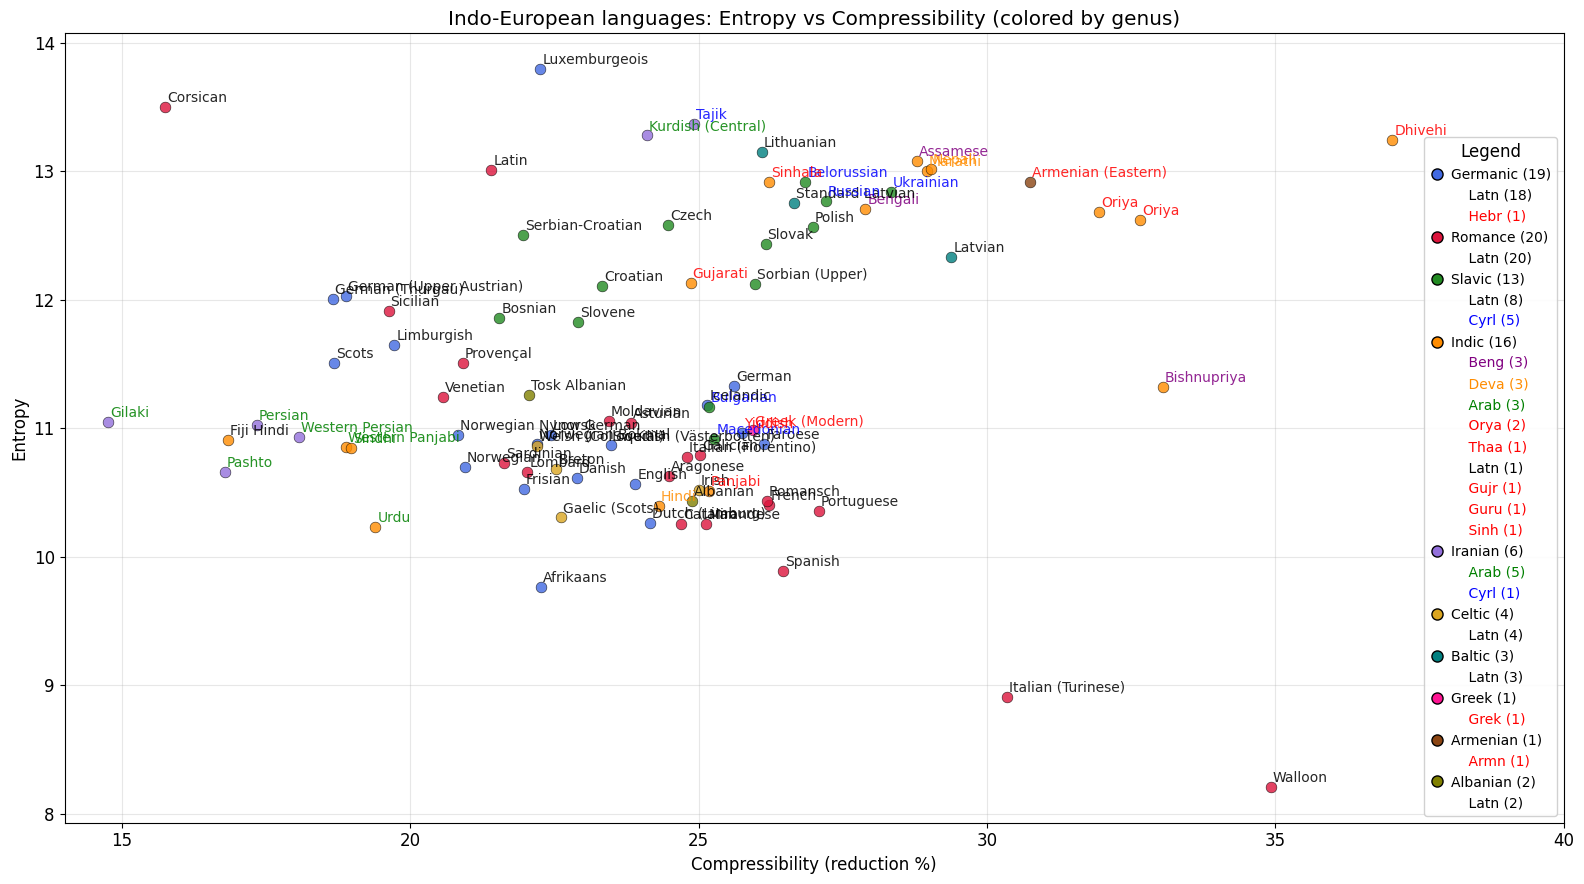

Indo-European languages plotted: 85
genus
Romance     20
Germanic    19
Indic       16
Slavic      13
Iranian      6
Celtic       4
Baltic       3
Albanian     2
Greek        1
Armenian     1


In [168]:
# Indo-European languages: Entropy vs Compressibility, colored by genus
from matplotlib.lines import Line2D

df_ie = df.dropna(subset=["compress_reduction_pct", "token_frequency_entropy"]).copy()
df_ie = df_ie[df_ie["family"] == "Indo-European"].copy()

SCRIPT_COLORS = {
    "Latn": "black", "Cyrl": "blue", "Arab": "green",
    "Deva": "darkorange", "Beng": "purple",
}
GENUS_COLORS = {
    "Germanic": "royalblue", "Romance": "crimson", "Slavic": "forestgreen",
    "Indic": "darkorange", "Iranian": "mediumpurple", "Celtic": "goldenrod",
    "Baltic": "teal", "Greek": "deeppink", "Armenian": "saddlebrown", "Albanian": "olive",
}

def ie_script_color(s):
    return SCRIPT_COLORS.get(s, "red")

fig, ax = plt.subplots(figsize=(16, 9))

for genus, color in GENUS_COLORS.items():
    subset = df_ie[df_ie["genus"] == genus]
    if subset.empty:
        continue
    ax.scatter(subset["compress_reduction_pct"], subset["token_frequency_entropy"],
               s=60, alpha=0.8, c=color, edgecolors="k", linewidths=0.4, zorder=3)

for _, row in df_ie.iterrows():
    ax.annotate(row["language"], (row["compress_reduction_pct"], row["token_frequency_entropy"]),
                xytext=(2, 2), textcoords="offset pixels",
                fontsize=10, alpha=0.85, ha="left", va="bottom",
                color=ie_script_color(row["script"]))

ax.set_xlabel("Compressibility (reduction %)")
ax.set_ylabel("Entropy")
ax.set_xlim(14, 40)
ax.set_title("Indo-European languages: Entropy vs Compressibility (colored by genus)")
ax.grid(alpha=0.3)

# Legend: genus dots + script breakdown
legend_handles, legend_labels, legend_colors = [], [], []
for genus, genus_color in GENUS_COLORS.items():
    subset = df_ie[df_ie["genus"] == genus]
    if subset.empty:
        continue
    legend_handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor=genus_color,
                                  markeredgecolor="k", markersize=8))
    legend_labels.append(f"{genus} ({len(subset)})")
    legend_colors.append("black")
    for script, count in subset["script"].value_counts().items():
        legend_handles.append(Line2D([0], [0], marker="", linestyle="", markersize=0))
        legend_labels.append(f"    {script} ({count})")
        legend_colors.append(ie_script_color(script))

leg = ax.legend(legend_handles, legend_labels, title="Legend", loc="lower right",
                fontsize=10, framealpha=0.9, handlelength=1, handletextpad=0.5)
for text, c in zip(leg.get_texts(), legend_colors):
    text.set_color(c)

plt.tight_layout()
graph_export.save("ie_entropy_compressibility", fig)
plt.show()

print(f"Indo-European languages plotted: {len(df_ie)}")
print(df_ie["genus"].value_counts().to_string())

graph_export: saved zipfSlopeComparison.pdf


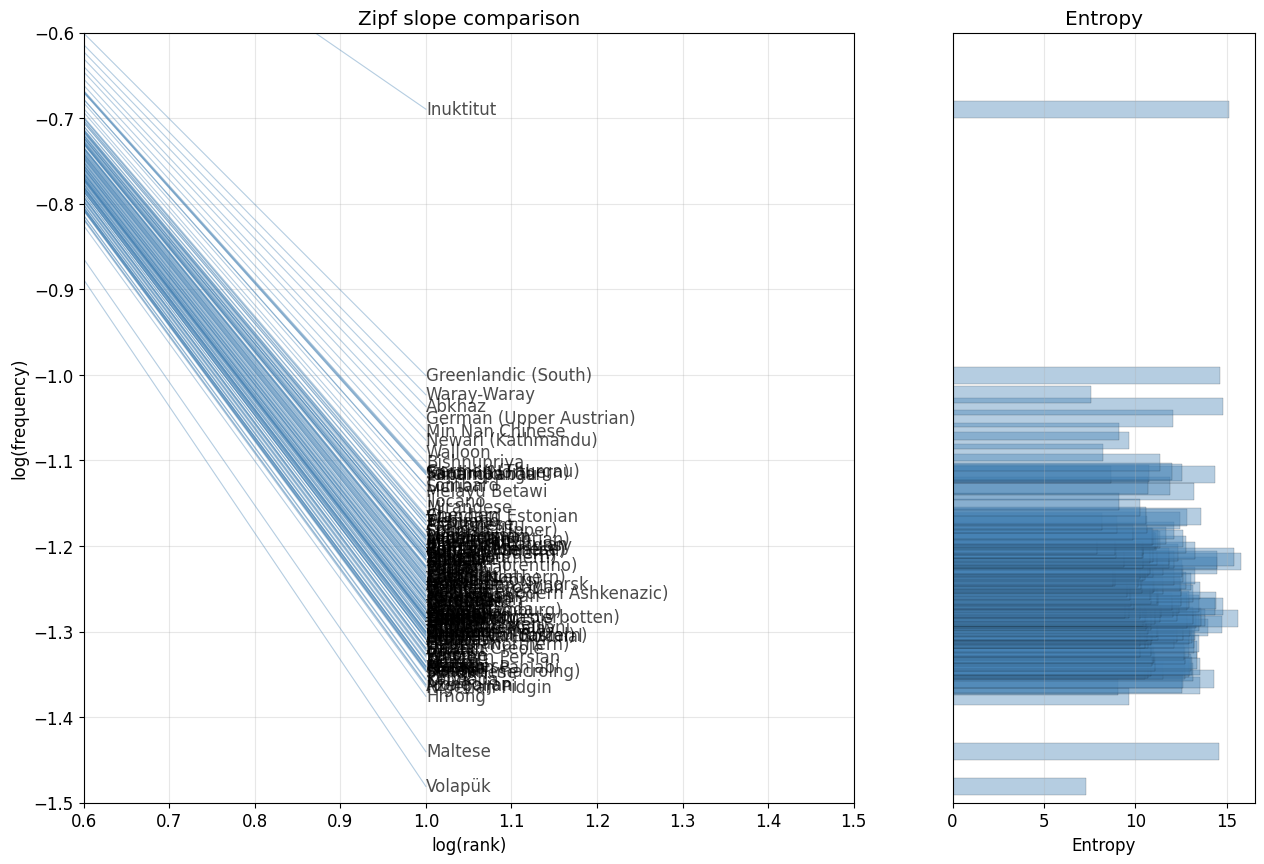

Languages plotted: 173

Steepest slopes:
       language  corpus_zipf_slope
        Volapük          -1.480940
        Maltese          -1.440412
          Hmong          -1.375624
Nigerian Pidgin          -1.364659
    Azerbaijani          -1.362638

Shallowest slopes:
               language  corpus_zipf_slope
              Inuktitut          -0.689359
    Greenlandic (South)          -1.000779
            Waray-Waray          -1.023198
                 Abkhaz          -1.037019
German (Upper Austrian)          -1.050582


In [ ]:
df_zipf = df.dropna(subset=["corpus_zipf_slope", "token_frequency_entropy"]).copy()
df_zipf = df_zipf.sort_values("corpus_zipf_slope")

fig, (ax, ax_bar) = plt.subplots(1, 2, figsize=(16, 10),
                                  gridspec_kw={"width_ratios": [3, 1], "wspace": 0.05})

line_len = 1.0
y_positions = []
for _, row in df_zipf.iterrows():
    slope = row["corpus_zipf_slope"]
    y_pos = slope * line_len
    y_positions.append(y_pos)
    ax.plot([0, line_len], [0, y_pos], alpha=0.4, linewidth=0.8, color="steelblue")
    ax.annotate(row["language"], (line_len, y_pos), fontsize=FONT_SIZE, alpha=0.7, ha="left", va="center")

ax.axhline(0, color="k", linewidth=0.5, linestyle="--", alpha=0.3)
ax.set_xlim(0.6, 1.5)
ax.set_ylim(-1.5, -0.6)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("log(rank)")
ax.set_ylabel("log(frequency)")
ax.set_title("Zipf slope comparison")
ax.grid(alpha=0.3)

y_arr = np.array(y_positions)
ax_bar.barh(y_arr, df_zipf["token_frequency_entropy"].values,
            height=0.02, color="steelblue", alpha=0.4, edgecolor="k", linewidth=0.3)
ax_bar.set_ylim(ax.get_ylim())
ax_bar.set_xlabel("Entropy")
ax_bar.set_title("Entropy")
ax_bar.set_yticklabels([])
ax_bar.set_yticks([])
ax_bar.grid(axis="x", alpha=0.3)

graph_export.save("zipfSlopeComparison", fig)
plt.show()

print(f"Languages plotted: {len(df_zipf)}")
print(f"\nSteepest slopes:")
print(df_zipf.nsmallest(5, "corpus_zipf_slope")[["language", "corpus_zipf_slope"]].to_string(index=False))
print(f"\nShallowest slopes:")
print(df_zipf.nlargest(5, "corpus_zipf_slope")[["language", "corpus_zipf_slope"]].to_string(index=False))

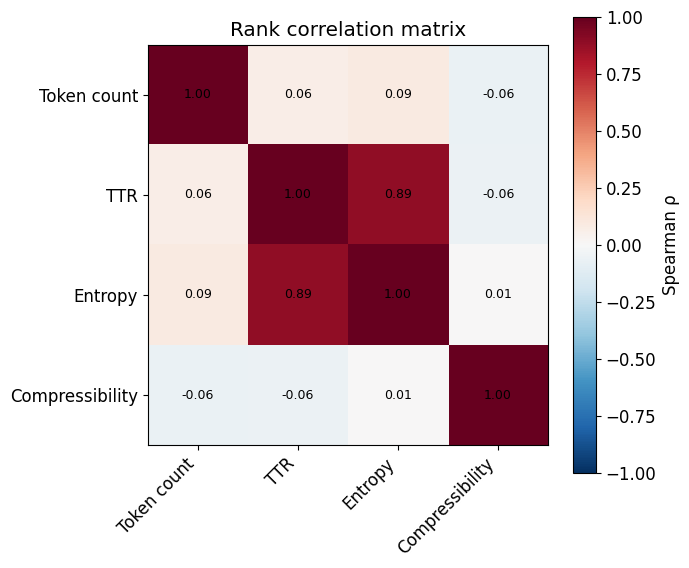

In [162]:
# Spearman correlation matrix
df_corr = df[["original_token_count", "type_token_ratio", "token_frequency_entropy", "compress_reduction_pct"]].dropna()
df_corr.columns = ["Token count", "TTR", "Entropy", "Compressibility"]

corr = df_corr.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Spearman ρ")
ax.set_title("Rank correlation matrix")
plt.tight_layout()
plt.show()

graph_export: saved compressibility_by_script_violin.pdf


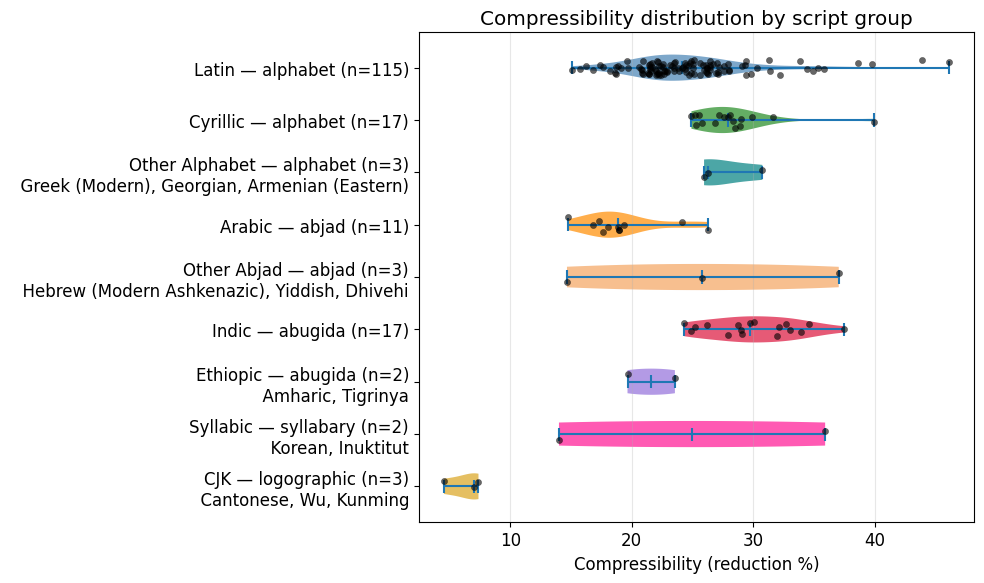


Total languages: 173
script_group
Latin             115
Cyrillic           17
Indic              17
Arabic             11
CJK                 3
Other Alphabet      3
Other Abjad         3
Ethiopic            2
Syllabic            2


In [163]:
# Violin: Compressibility by script group
INDIC_SCRIPTS = {"Deva", "Beng", "Orya", "Gujr", "Guru", "Sinh", "Knda", "Mlym", "Taml", "Telu", "Thai", "Khmr", "Mymr", "Laoo", "Tibt"}
CJK_SCRIPTS = {"Hani"}
SYLLABIC_SCRIPTS = {"Hang", "Cans"}
ARABIC_SCRIPTS = {"Arab"}
OTHER_ABJAD_SCRIPTS = {"Hebr", "Thaa"}
GREEK_ARM_GEO = {"Grek", "Armn", "Geor"}

SCRIPT_TYPOLOGY = {
    "Latin": "alphabet", "Cyrillic": "alphabet", "Other Alphabet": "alphabet",
    "Arabic": "abjad", "Other Abjad": "abjad",
    "Indic": "abugida", "Ethiopic": "abugida",
    "Syllabic": "syllabary", "CJK": "logographic",
}

GROUP_ORDER = ["CJK", "Syllabic", "Ethiopic", "Indic", "Other Abjad", "Arabic",
               "Other Alphabet", "Cyrillic", "Latin"]

SCRIPT_GROUP_COLORS = {
    "Latin": "steelblue", "Cyrillic": "forestgreen", "Other Alphabet": "teal",
    "Arabic": "darkorange", "Other Abjad": "sandybrown", "Indic": "crimson",
    "Ethiopic": "mediumpurple", "Syllabic": "deeppink", "CJK": "goldenrod",
}

def assign_script_group(script):
    if script == "Latn": return "Latin"
    if script == "Cyrl": return "Cyrillic"
    if script in GREEK_ARM_GEO: return "Other Alphabet"
    if script in ARABIC_SCRIPTS: return "Arabic"
    if script in OTHER_ABJAD_SCRIPTS: return "Other Abjad"
    if script in INDIC_SCRIPTS: return "Indic"
    if script == "Ethi": return "Ethiopic"
    if script in SYLLABIC_SCRIPTS: return "Syllabic"
    if script in CJK_SCRIPTS: return "CJK"
    return None

df_violin = df.dropna(subset=["compress_reduction_pct"]).copy()
df_violin["script_group"] = df_violin["script"].apply(assign_script_group)
df_violin = df_violin.dropna(subset=["script_group"])

group_order = [g for g in GROUP_ORDER if g in df_violin["script_group"].values]
num_groups = len(group_order)
fig, ax = plt.subplots(figsize=(10, 0.5 * num_groups + 1.5))

data_by_group = [df_violin[df_violin["script_group"] == g]["compress_reduction_pct"].values for g in group_order]
counts = [len(d) for d in data_by_group]

labels = []
for g, c, data in zip(group_order, counts, data_by_group):
    base = f"{g} — {SCRIPT_TYPOLOGY[g]} (n={c})"
    if c < 4:
        group_df = df_violin[df_violin["script_group"] == g].sort_values("compress_reduction_pct")
        base += "\n  " + ", ".join(group_df["language"].tolist())
    labels.append(base)

parts = ax.violinplot(data_by_group, vert=False, showmedians=True, showextrema=True)
for pc, g in zip(parts["bodies"], group_order):
    pc.set_facecolor(SCRIPT_GROUP_COLORS.get(g, "gray"))
    pc.set_alpha(0.7)

rng = np.random.default_rng(42)
for i, (data, g) in enumerate(zip(data_by_group, group_order)):
    jitter = rng.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(data, (i + 1) + jitter, s=20, alpha=0.6,
               c="black", edgecolors="k", linewidths=0.3, zorder=3)

ax.set_yticks(range(1, len(group_order) + 1))
ax.set_yticklabels(labels, fontsize=FONT_SIZE)
ax.set_xlabel("Compressibility (reduction %)", fontsize=FONT_SIZE)
ax.set_title("Compressibility distribution by script group")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
graph_export.save("compressibility_by_script_violin", fig)
plt.show()

print(f"\nTotal languages: {len(df_violin)}")
print(df_violin["script_group"].value_counts().to_string())

graph_export: saved entropy_by_typology_violin.pdf


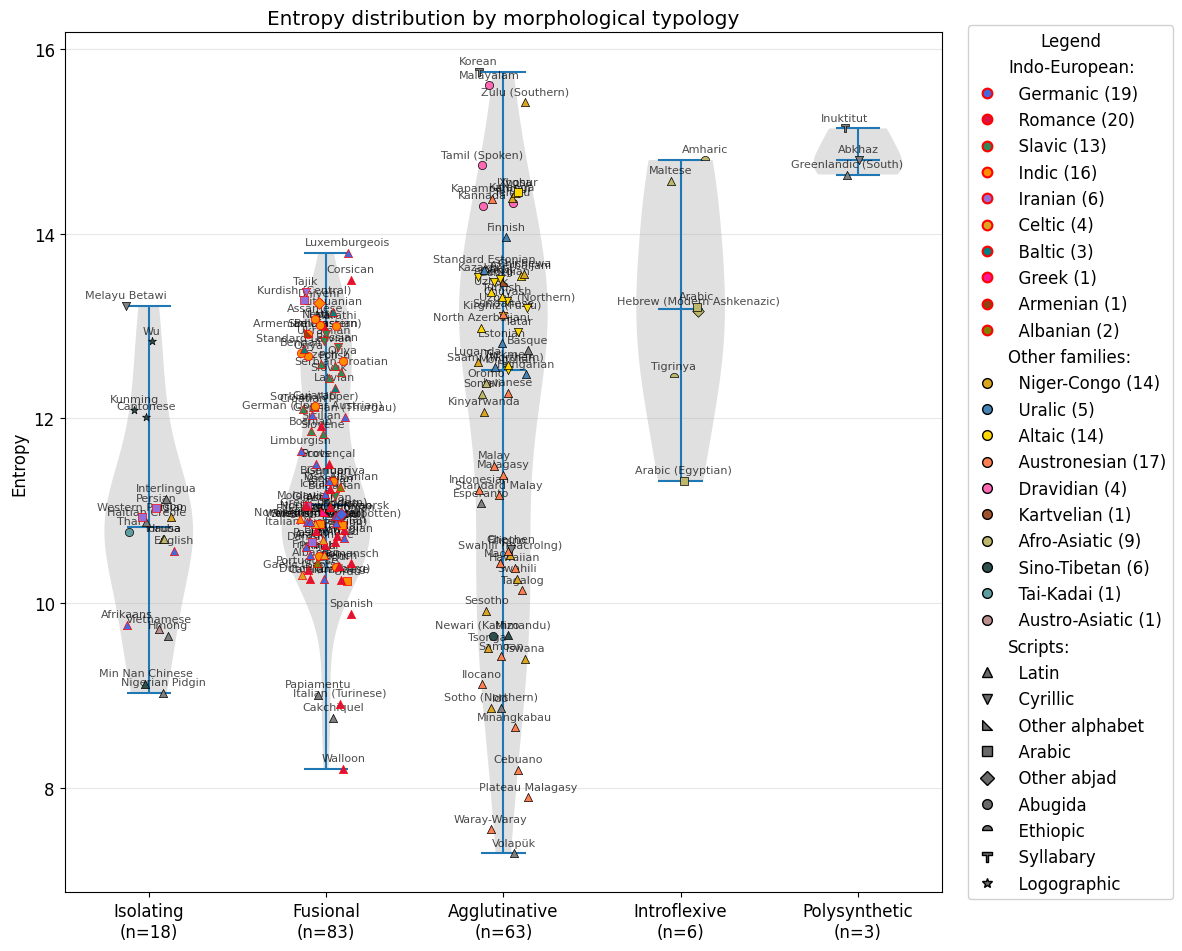


Median entropy by typology:
typology
Isolating        10.823577
Fusional         11.059631
Agglutinative    12.528341
Introflexive     13.188757
Polysynthetic    14.796891

Mean entropy by typology:
typology
Isolating        10.838270
Fusional         11.423901
Agglutinative    11.941957
Introflexive     13.253218
Polysynthetic    14.858822


In [ ]:
import lang_markers
from matplotlib.lines import Line2D

df_typo = df.dropna(subset=["token_frequency_entropy", "typology"]).copy()

TYPOLOGY_COLORS = {
    "Isolating": "crimson", "Fusional": "royalblue", "Agglutinative": "forestgreen",
    "Introflexive": "darkorange", "Polysynthetic": "mediumpurple",
}

typo_order = df_typo.groupby("typology")["token_frequency_entropy"].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))

data_by_typo = [df_typo[df_typo["typology"] == t]["token_frequency_entropy"].values for t in typo_order]
counts = [len(d) for d in data_by_typo]

parts = ax.violinplot(data_by_typo, vert=True, showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_facecolor("lightgray")
    pc.set_alpha(0.7)

rng = np.random.default_rng(42)
for i, t in enumerate(typo_order):
    subset = df_typo[df_typo["typology"] == t].sort_values("token_frequency_entropy")
    jitter = rng.uniform(-0.15, 0.15, size=len(subset))
    y_vals = subset["token_frequency_entropy"].values
    x_vals = (i + 1) + jitter
    for x, y, (_, row) in zip(x_vals, y_vals, subset.iterrows()):
        c = lang_markers.get_color(row)
        m = lang_markers.get_marker(row)
        ec = "red" if row["family"] == "Indo-European" else "k"
        ax.scatter(x, y, s=35, alpha=1, c=c, marker=m,
                   edgecolors=ec, linewidths=0.5, zorder=3)
        ax.annotate(row["language"], (x, y), fontsize=8, alpha=0.7, ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", zorder=4)

labels = [f"{t}\n(n={c})" for t, c in zip(typo_order, counts)]
ax.set_xticks(range(1, len(typo_order) + 1))
ax.set_xticklabels(labels, fontsize=FONT_SIZE)
ax.set_ylabel("Entropy", fontsize=FONT_SIZE)
ax.set_title("Entropy distribution by morphological typology")
ax.grid(axis="y", alpha=0.3)

color_handles = lang_markers.build_color_legend(df_typo, counts=True)
for h in color_handles:
    if h.get_label().startswith("  ") and h.get_label().strip().split(" ")[0] in lang_markers.IE_GENUS_COLORS:
        h.set_markeredgecolor("red")
        h.set_markeredgewidth(1.5)

script_handles = lang_markers.build_script_legend()
leg = ax.legend(handles=color_handles + script_handles, title="Legend",
                loc="center left", bbox_to_anchor=(1.02, 0.5),
                fontsize=FONT_SIZE, title_fontsize=FONT_SIZE,
                framealpha=0.9, handlelength=1.5, handletextpad=0.5)

plt.tight_layout()
graph_export.save("entropy_by_typology_violin", fig)
plt.show()

print("\nMedian entropy by typology:")
print(df_typo.groupby("typology")["token_frequency_entropy"].median().sort_values().to_string())
print("\nMean entropy by typology:")
print(df_typo.groupby("typology")["token_frequency_entropy"].mean().sort_values().to_string())